In [ ]:
# basico
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import datetime
import scipy.stats as stats

# preprocesado
from sklearn.model_selection import train_test_split
!pip install ydata-profiling
from ydata_profiling import ProfileReport

# modelado
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# metricas
from pandas.plotting import scatter_matrix
from sklearn.metrics import accuracy_score, auc, confusion_matrix, f1_score, precision_score, recall_score, roc_curve
from sklearn.metrics import classification_report


# mejora de modelos
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score

## automatización
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.4 MB/s eta 0:00:00


# Lectura de datos

### Variables independientes

In [ ]:
train_val = pd.read_csv('training_set_values.csv')

In [ ]:
train_val.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe


In [ ]:
train_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55763 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

In [ ]:
train_val['id'].duplicated().value_counts()

,count
id,
False,59400


### Variable objetivo

In [ ]:
train_label = pd.read_csv('training_set_labels.csv')

In [ ]:
train_label

,id,status_group
0,69572,functional
1,8776,functional
2,34310,functional
3,67743,non functional
4,19728,functional
...,...,...
59395,60739,functional
59396,27263,functional
59397,37057,functional
59398,31282,functional


In [ ]:
train_label.nunique()

,0
id,59400
status_group,3


In [ ]:
# Vemos que 3 valores posibles puede tener la objetivo

train_label['status_group'].unique()

array(['functional', 'non functional', 'functional needs repair'],
      dtype=object)

### Test para variables independientes

In [ ]:
test_val = pd.read_csv('test_set_values.csv')

In [ ]:
test_val

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,50785,0.0,2013-02-04,Dmdd,1996,DMDD,35.290799,-4.059696,Dinamu Secondary School,0,...,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,other,other
1,51630,0.0,2013-02-04,Government Of Tanzania,1569,DWE,36.656709,-3.309214,Kimnyak,0,...,never pay,soft,good,insufficient,insufficient,spring,spring,groundwater,communal standpipe,communal standpipe
2,17168,0.0,2013-02-01,NaN,1567,NaN,34.767863,-5.004344,Puma Secondary,0,...,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,other,other
3,45559,0.0,2013-01-22,Finn Water,267,FINN WATER,38.058046,-9.418672,Kwa Mzee Pange,0,...,unknown,soft,good,dry,dry,shallow well,shallow well,groundwater,other,other
4,49871,500.0,2013-03-27,Bruder,1260,BRUDER,35.006123,-10.950412,Kwa Mzee Turuka,0,...,monthly,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14845,39307,0.0,2011-02-24,Danida,34,Da,38.852669,-6.582841,Kwambwezi,0,...,never pay,soft,good,enough,enough,river,river/lake,surface,communal standpipe,communal standpipe
14846,18990,1000.0,2011-03-21,Hiap,0,HIAP,37.451633,-5.350428,Bonde La Mkondoa,0,...,annually,salty,salty,insufficient,insufficient,shallow well,shallow well,groundwater,hand pump,hand pump
14847,28749,0.0,2013-03-04,NaN,1476,NaN,34.739804,-4.585587,Bwawani,0,...,never pay,soft,good,insufficient,insufficient,dam,dam,surface,communal standpipe,communal standpipe
14848,33492,0.0,2013-02-18,Germany,998,DWE,35.432732,-10.584159,Kwa John,0,...,never pay,soft,good,insufficient,insufficient,river,river/lake,surface,communal standpipe,communal standpipe


Veamos si los **id** de la tabla de variables independientes coinciden con los de la variable objetivo

In [ ]:
train_label['id'].isin(train_val['id']).value_counts()

# vemos que coinciden todos, a la hora de juntarlos en un solo tablon no habra porblema

,count
id,
True,59400


Vamos ahora a unir los conjuntos de train y test. Hay 59400 datos en train y 14850 en test.
En totoal son 74250 registros. $\frac{14850}{74250} = 0,2 $

Por lo tanto la particion training/test es 80/20

In [ ]:
train_val['particion'] = 'train'
test_val['particion'] = 'test'

In [ ]:
df = pd.concat([train_val, test_val], sort = False, ignore_index = True)
df

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,particion
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,train
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,train
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,train
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,train
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74245,39307,0.0,2011-02-24,Danida,34,Da,38.852669,-6.582841,Kwambwezi,0,...,soft,good,enough,enough,river,river/lake,surface,communal standpipe,communal standpipe,test
74246,18990,1000.0,2011-03-21,Hiap,0,HIAP,37.451633,-5.350428,Bonde La Mkondoa,0,...,salty,salty,insufficient,insufficient,shallow well,shallow well,groundwater,hand pump,hand pump,test
74247,28749,0.0,2013-03-04,NaN,1476,NaN,34.739804,-4.585587,Bwawani,0,...,soft,good,insufficient,insufficient,dam,dam,surface,communal standpipe,communal standpipe,test
74248,33492,0.0,2013-02-18,Germany,998,DWE,35.432732,-10.584159,Kwa John,0,...,soft,good,insufficient,insufficient,river,river/lake,surface,communal standpipe,communal standpipe,test


# Pre-procesado

Para empezar, vamos a transformar la variable **date_recorded** , para obtener el año, dia y mes.

In [ ]:
df['date_recorded'] = pd.to_datetime(df['date_recorded'])

In [ ]:
df['year'] = df['date_recorded'].dt.year
df['month'] = df['date_recorded'].dt.month
df['day'] = df['date_recorded'].dt.day

In [ ]:
df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,particion,year,month,day
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,enough,spring,spring,groundwater,communal standpipe,communal standpipe,train,2011,3,14
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,train,2013,3,6
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,train,2013,2,25
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,train,2013,1,28
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,train,2011,7,13


In [ ]:
# y eliminamos la variable original
df.drop(columns='date_recorded', inplace=True)

In [ ]:
df['year'].unique()

array([2011, 2013, 2012, 2004, 2002, 2001], dtype=int32)

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

In [ ]:
df[cat_cols].describe()

,funder,installer,wpt_name,basin,subvillage,region,lga,ward,public_meeting,recorded_by,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,particion
count,69743,69718,74248,74250,73780,74250,74250,74250,70095,74250,...,74250,74250,74250,74250,74250,74250,74250,74250,74250,74250
unique,2139,2410,45683,9,21425,21,125,2098,2,1,...,8,6,5,5,10,7,3,7,6,2
top,Government Of Tanzania,DWE,none,Lake Victoria,Shuleni,Iringa,Njombe,Igosi,True,GeoData Consultants Ltd,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,train
freq,11299,21751,4440,12871,646,6599,3128,386,63749,74250,...,63505,63505,41522,41522,21216,21216,57286,35628,43239,59400


In [ ]:
df[num_cols].describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year,year,month,day
count,74250.000000,74250.000000,74250.000000,74250.000000,7.425000e+04,74250.000000,74250.000000,74250.000000,74250.000000,74250.000000,74250.000000,74250.000000,74250.000000
mean,37124.500000,318.685704,665.667313,34.074262,-5.701771e+00,0.462330,15.265414,5.629077,180.750828,1298.463650,2011.918559,4.381347,15.612229
std,21434.273081,2906.762364,692.761033,6.572519,2.944969e+00,11.537879,17.508907,9.641636,471.086120,952.349375,0.960299,3.031019,8.687416
min,0.000000,0.000000,-90.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000,2001.000000,1.000000,1.000000
25%,18562.250000,0.000000,0.000000,33.086819,-8.525675e+00,0.000000,5.000000,2.000000,0.000000,0.000000,2011.000000,2.000000,8.000000
50%,37124.500000,0.000000,364.000000,34.907475,-5.026540e+00,0.000000,12.000000,3.000000,25.000000,1986.000000,2012.000000,3.000000,16.000000
75%,55686.750000,20.000000,1317.000000,37.181685,-3.325058e+00,0.000000,17.000000,5.000000,215.000000,2004.000000,2013.000000,7.000000,23.000000
max,74249.000000,350000.000000,2777.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000,2013.000000,12.000000,31.000000


In [ ]:
#prof = ProfileReport(df)
#prof.to_file(output_file='output.html')

### Tratramiento de nulos

In [ ]:
df.isnull().sum()

,0
id,0
amount_tsh,0
funder,4507
gps_height,0
installer,4532
longitude,0
latitude,0
wpt_name,2
num_private,0
basin,0


Vemos que las sigiuentes 8 variables tienen valores nulos: **Funder, installer, wpt_name, subvillage, public_meeting, scheme_management, scheme_name** y **permit**

**Funder**: Vemos que hay muchos registros, y muchos valores unicos. Vamos a sustituir los valores perdidios por desconocidos y como tienemos mucha cardinalidad, tomamos el top 20 y el resto lo cambiamos a otros.

In [ ]:
df.funder.value_counts().head(30)

,count
funder,
Government Of Tanzania,11299
Danida,3907
Hesawa,2782
Rwssp,1703
World Bank,1701
Kkkt,1623
World Vision,1562
Unicef,1324
Tasaf,1136


In [ ]:
df['funder'].nunique()

2139

In [ ]:
df['funder'] = df['funder'].fillna('Unknown')

top = df['funder'].value_counts().nlargest(20).index
df['funder'] = df['funder'].apply(lambda x: x if x in top else 'Other')

In [ ]:
df['funder'].value_counts()

,count
funder,
Other,33657
Government Of Tanzania,11299
Unknown,4512
Danida,3907
Hesawa,2782
Rwssp,1703
World Bank,1701
Kkkt,1623
World Vision,1562


**Installer:** Lo mismo que con funder

In [ ]:
df.installer.value_counts().head(30)

,count
installer,
DWE,21751
Government,2282
RWE,1498
Commu,1347
DANIDA,1305
KKKT,1120
Hesawa,1070
0,980
TCRS,887


In [ ]:
df.installer.nunique()

2410

In [ ]:
df['installer'] = df['installer'].fillna('Unknown')

top = df['installer'].value_counts().nlargest(20).index
df['installer'] = df['installer'].apply(lambda x: x if x in top else 'Other')

In [ ]:
df.installer.value_counts()

,count
installer,
Other,31208
DWE,21751
Unknown,4536
Government,2282
RWE,1498
Commu,1347
DANIDA,1305
KKKT,1120
Hesawa,1070


**wpt_name:** En este caso vamos a cambiar la variable, ya que nos dice el nombre del waterpoint si hay uno, por una binaria: hay o no hay waterpoint. Teniamos 2 valores perdidos pero al hacer el cambio, estos valores se han convertido en 1's.

In [ ]:
df.wpt_name.value_counts()

,count
wpt_name,
none,4440
Shuleni,2183
Zahanati,1034
Msikitini,647
Kanisani,390
...,...
Kituo Cha Liheta,1
Kwa Juma Lukanda,1
Buliambuli,1


In [ ]:
df['wpt_bi'] = df['wpt_name'].apply(lambda x: 0 if x == 'none' else 1)

In [ ]:
df.wpt_bi.value_counts()

,count
wpt_bi,
1,69810
0,4440


In [ ]:
df.drop(columns='wpt_name', inplace=True)

**subvillage:** Hay muchos valores y va a ser dificil de tramificar o de convertir en dummies. Se nos ocurre, como es una localizacion geografica y ya tenemos variables numericas que representan las localizacion geografica (region_code y district_code), **quitar las siguientes variables** del DataFrame : **subvillage, region, lga** y **ward**.

In [ ]:
df.loc[:,['subvillage','region','region_code','district_code','lga','ward']]

,subvillage,region,region_code,district_code,lga,ward
0,Mnyusi B,Iringa,11,5,Ludewa,Mundindi
1,Nyamara,Mara,20,2,Serengeti,Natta
2,Majengo,Manyara,21,4,Simanjiro,Ngorika
3,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu
4,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi
...,...,...,...,...,...,...
74245,Yombo,Pwani,6,1,Bagamoyo,Yombo
74246,Mkondoa,Tanga,4,7,Kilindi,Mvungwe
74247,Juhudi,Singida,13,2,Singida Rural,Ughandi
74248,Namakinga B,Ruvuma,10,2,Songea Rural,Maposeni


In [ ]:
df.groupby('region')['region_code'].nunique()

# asi vemos cuantos codigos de region tiene cada region

,region_code
region,
Arusha,2
Dar es Salaam,1
Dodoma,1
Iringa,1
Kagera,1
Kigoma,1
Kilimanjaro,1
Lindi,3
Manyara,1


In [ ]:
df.loc[df['region'] == 'Mwanza', 'region_code'].unique()

array([19, 17, 12])

region_code tiene mas granularidad que region, es decir como tiene mas de un codigo por region, suponemos que debe ser porque dentro de la region tiene que haber otra subdivision. Por este motivo eliminamos region y nos quedamos solo con region_code.

In [ ]:
df.subvillage.value_counts()

,count
subvillage,
Shuleni,646
Majengo,631
Madukani,629
Kati,467
Mtakuja,322
...,...
Kirumuni,1
Igalagala,1
Namwaya,1


In [ ]:
df.subvillage.nunique()

21425

In [ ]:
df.drop(columns=['subvillage', 'region', 'lga', 'ward'], inplace=True)

**public meeting:** vamos a crear un valor desconocido, no se sabe si hubo una charla publica.

In [ ]:
df.public_meeting.value_counts()

,count
public_meeting,
True,63749
False,6346


In [ ]:
df.public_meeting.fillna('Unknown', inplace=True)

/tmp/ipykernel_15153/793118686.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.public_meeting.fillna('Unknown', inplace=True)


In [ ]:
df.public_meeting.value_counts()

,count
public_meeting,
True,63749
False,6346
Unknown,4155


**scheme management:** creamos una nueva categoria desconocido

In [ ]:
df.scheme_management.value_counts()

,count
scheme_management,
VWC,45917
WUG,6496
Water authority,3975
WUA,3551
Water Board,3462
Parastatal,2124
Company,1341
Private operator,1326
Other,996


In [ ]:
df.scheme_management.nunique()

11

In [ ]:
df.scheme_management.fillna('Unknown', inplace=True)

/tmp/ipykernel_15153/73817140.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.scheme_management.fillna('Unknown', inplace=True)


**scheme_name**: como ya tenemos varias variables que nos dan quien opera el waterpoint, eliminamos esta variable

In [ ]:
df.drop(columns='scheme_name', inplace=True)

**permit:** lo mismo que hicimos con public meeting

In [ ]:
df.permit.value_counts()

,count
permit,
True,48606
False,21851


In [ ]:
df.permit.fillna('Unknown', inplace=True)

/tmp/ipykernel_15153/351273698.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.permit.fillna('Unknown', inplace=True)


In [ ]:
df.permit.value_counts()

,count
permit,
True,48606
False,21851
Unknown,3793


In [ ]:
df.isnull().sum()

,0
id,0
amount_tsh,0
funder,0
gps_height,0
installer,0
longitude,0
latitude,0
num_private,0
basin,0
region_code,0


### Eliminacion de variables redundantes

vamos a quitar variables que no aportan nueva informacion, ya que hay muchas y estan correladas unas con otras.

**recorde_by:**

In [ ]:
df.recorded_by.nunique()

1

In [ ]:
df.recorded_by.value_counts()

,count
recorded_by,
GeoData Consultants Ltd,74250


**recorded_by** es una variable **constante**, no nos sirve a la hora de hacer el modelo.

In [ ]:
df.drop(columns='recorded_by', inplace=True)

**extraction_type:**

In [ ]:
df.extraction_type.value_counts()

,count
extraction_type,
gravity,33263
nira/tanira,10205
other,8102
submersible,5982
swn 80,4588
mono,3628
india mark ii,3029
afridev,2208
ksb,1790


In [ ]:
df.extraction_type_class.value_counts()

,count
extraction_type_class,
gravity,33263
handpump,20612
other,8102
submersible,7772
motorpump,3777
rope pump,572
wind-powered,152


In [ ]:
df.extraction_type_group.value_counts()

,count
extraction_type_group,
gravity,33263
nira/tanira,10205
other,8102
submersible,7772
swn 80,4588
mono,3628
india mark ii,3029
afridev,2208
rope pump,572


parece que **extraction type class** es la variable mas compacta. **eliminamos** las otras **dos extraction type**

In [ ]:
df.drop(columns=['extraction_type', 'extraction_type_group'], inplace=True)

**management**:

In [ ]:
df.management.value_counts()

,count
management,
vwc,50624
wug,8108
water board,3688
wua,3118
private operator,2504
parastatal,2229
water authority,1123
other,1083
company,859


In [ ]:
df.management_group.value_counts()

,count
management_group,
user-group,65538
commercial,4591
parastatal,2229
other,1209
unknown,683


nos quedamos con **management group**

In [ ]:
df.drop(columns='management', inplace=True)

**payment**:

In [ ]:
df.payment.value_counts()

,count
payment,
never pay,31712
pay per bucket,11266
pay monthly,10397
unknown,10149
pay when scheme fails,4842
pay annually,4570
other,1314


In [ ]:
df.payment_type.value_counts()

,count
payment_type,
never pay,31712
per bucket,11266
monthly,10397
unknown,10149
on failure,4842
annually,4570
other,1314


Estas dos estan duplicadas, nos quedamos con **payment type**

In [ ]:
df.drop(columns='payment', inplace=True)

**water quality**:

In [ ]:
df.water_quality.value_counts()

,count
water_quality,
soft,63505
salty,6082
unknown,2345
milky,1005
coloured,623
salty abandoned,423
fluoride,244
fluoride abandoned,23


In [ ]:
df.quality_group.value_counts()

,count
quality_group,
good,63505
salty,6505
unknown,2345
milky,1005
colored,623
fluoride,267


nos quedamos con **quality_group**

In [ ]:
df.drop(columns='water_quality', inplace=True)

**quantity:**

In [ ]:
df.quantity.value_counts()

,count
quantity,
enough,41522
insufficient,18896
dry,7782
seasonal,5075
unknown,975


In [ ]:
df.quantity_group.value_counts()

,count
quantity_group,
enough,41522
insufficient,18896
dry,7782
seasonal,5075
unknown,975


repetidas, nos quedamos con **quantity**

In [ ]:
df.drop(columns='quantity_group', inplace=True)

**source**:

In [ ]:
df.source.value_counts()

,count
source,
spring,21216
shallow well,21140
machine dbh,13822
river,11964
rainwater harvesting,2863
hand dtw,1108
lake,950
dam,840
other,261


In [ ]:
df.source_class.value_counts()

,count
source_class,
groundwater,57286
surface,16617
unknown,347


In [ ]:
df.source_type.value_counts()

,count
source_type,
spring,21216
shallow well,21140
borehole,14930
river/lake,12914
rainwater harvesting,2863
dam,840
other,347


nos quedamos con **source class**

In [ ]:
df.drop(columns=['source', 'source_type'], inplace=True)

**waterpoint**:

In [ ]:
df.waterpoint_type.value_counts()

,count
waterpoint_type,
communal standpipe,35628
hand pump,21884
other,8010
communal standpipe multiple,7611
improved spring,959
cattle trough,150
dam,8


In [ ]:
df.waterpoint_type_group.value_counts()

,count
waterpoint_type_group,
communal standpipe,43239
hand pump,21884
other,8010
improved spring,959
cattle trough,150
dam,8


In [ ]:
df.drop(columns='waterpoint_type', inplace=True)

## Dataframe con las variables eliminadas

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74250 entries, 0 to 74249
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     74250 non-null  int64  
 1   amount_tsh             74250 non-null  float64
 2   funder                 74250 non-null  object 
 3   gps_height             74250 non-null  int64  
 4   installer              74250 non-null  object 
 5   longitude              74250 non-null  float64
 6   latitude               74250 non-null  float64
 7   num_private            74250 non-null  int64  
 8   basin                  74250 non-null  object 
 9   region_code            74250 non-null  int64  
 10  district_code          74250 non-null  int64  
 11  population             74250 non-null  int64  
 12  public_meeting         74250 non-null  object 
 13  scheme_management      74250 non-null  object 
 14  permit                 74250 non-null  object 
 15  co

In [ ]:
df.nunique()

,0
id,74250
amount_tsh,102
funder,21
gps_height,2456
installer,21
longitude,71870
latitude,71869
num_private,68
basin,9
region_code,27


# Transformacion en numero ordinal

In [ ]:
list_cat = df.select_dtypes(include='object').columns
list_cat

Index(['funder', 'installer', 'basin', 'public_meeting', 'scheme_management',
       'permit', 'extraction_type_class', 'management_group', 'payment_type',
       'quality_group', 'quantity', 'source_class', 'waterpoint_type_group',
       'particion'],
      dtype='object')

In [ ]:
df.funder.unique()

array(['Other', 'Unicef', 'Dwsp', 'Rwssp', 'Danida', 'World Vision',
       'Hesawa', 'Government Of Tanzania', 'Water', 'Private Individual',
       'Unknown', 'District Council', 'Kkkt', 'Norad', 'Tcrs',
       'Germany Republi', 'Tasaf', 'World Bank', '0', 'Dhv',
       'Ministry Of Water'], dtype=object)

In [ ]:
df.funder.replace(('Other', 'Unicef', 'Dwsp', 'Rwssp', 'Danida', 'World Vision',
       'Hesawa', 'Government Of Tanzania', 'Water', 'Private Individual',
       'Unknown', 'District Council', 'Kkkt', 'Norad', 'Tcrs',
       'Germany Republi', 'Tasaf', 'World Bank', '0', 'Dhv',
       'Ministry Of Water'),(1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21), inplace= True)

/tmp/ipykernel_15153/208869163.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.funder.replace(('Other', 'Unicef', 'Dwsp', 'Rwssp', 'Danida', 'World Vision',
/tmp/ipykernel_15153/208869163.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.funder.replace(('Other', 'Unicef', 'Dwsp', 'Rwssp'

In [ ]:
df.funder = df.funder.astype(int)

In [ ]:
df.installer.unique()

array(['Other', 'World vision', 'DWE', 'DANIDA', 'WEDECO', 'Unknown',
       'Central government', 'Commu', 'LGA', 'Government', 'KKKT', 'RWE',
       'HESAWA', 'Community', 'CES', 'Hesawa', 'TASAF', '0', 'DANID',
       'TCRS', 'District Council'], dtype=object)

In [ ]:
df.installer.replace(('Other', 'World vision', 'DWE', 'DANIDA', 'WEDECO', 'Unknown',
       'Central government', 'Commu', 'LGA', 'Government', 'KKKT', 'RWE',
       'HESAWA', 'Community', 'CES', 'Hesawa', 'TASAF', '0', 'DANID',
       'TCRS', 'District Council'),(1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21), inplace= True)

/tmp/ipykernel_15153/3656964842.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.installer.replace(('Other', 'World vision', 'DWE', 'DANIDA', 'WEDECO', 'Unknown',
/tmp/ipykernel_15153/3656964842.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.installer.replace(('Other', 'World vision', 

In [ ]:
df.installer = df.installer.astype(int)

In [ ]:
df.basin.unique()

array(['Lake Nyasa', 'Lake Victoria', 'Pangani',
       'Ruvuma / Southern Coast', 'Internal', 'Lake Tanganyika',
       'Wami / Ruvu', 'Rufiji', 'Lake Rukwa'], dtype=object)

In [ ]:
df.basin.replace(('Lake Nyasa', 'Lake Victoria', 'Pangani',
       'Ruvuma / Southern Coast', 'Internal', 'Lake Tanganyika',
       'Wami / Ruvu', 'Rufiji', 'Lake Rukwa'),(1,2,3,4,5,6,7,8,9), inplace=True)

/tmp/ipykernel_15153/3376906385.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.basin.replace(('Lake Nyasa', 'Lake Victoria', 'Pangani',
/tmp/ipykernel_15153/3376906385.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.basin.replace(('Lake Nyasa', 'Lake Victoria', 'Pangani',


In [ ]:
df.basin = df.basin.astype(int)

Vamos a hacer una lista de variables dummies, incluyendo las variables con 5 valores unicos o menos

In [ ]:
lista_dummies = ['public_meeting','permit','source_class','management_group','quantity']

In [ ]:
for k in lista_dummies:
  if k in df.columns: # Check if the column still exists in the DataFrame
    dummies = pd.get_dummies(df[k], prefix = k)
    df = pd.concat([df, dummies],axis = 1)
    df.drop(k,axis=1, inplace= True)

In [ ]:
df.scheme_management.unique()

array(['VWC', 'Other', 'Unknown', 'Private operator', 'WUG',
       'Water Board', 'WUA', 'Water authority', 'Company', 'Parastatal',
       'Trust', 'SWC'], dtype=object)

In [ ]:
df.scheme_management.replace(('VWC', 'Other', 'Unknown', 'Private operator', 'WUG',
       'Water Board', 'WUA', 'Water authority', 'Company', 'Parastatal',
       'Trust', 'SWC'),(1,2,3,4,5,6,7,8,9,10,11,12),inplace=True)

/tmp/ipykernel_15153/1340768745.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.scheme_management.replace(('VWC', 'Other', 'Unknown', 'Private operator', 'WUG',
/tmp/ipykernel_15153/1340768745.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.scheme_management.replace(('VWC', 'Other', 'U

In [ ]:
df.scheme_management = df.scheme_management.astype(int)

In [ ]:
df.extraction_type_class.unique()

array(['gravity', 'submersible', 'handpump', 'other', 'motorpump',
       'wind-powered', 'rope pump'], dtype=object)

In [ ]:
df.extraction_type_class.replace(('gravity', 'submersible', 'handpump', 'other', 'motorpump',
       'wind-powered', 'rope pump'),(1,2,3,4,5,6,7),inplace=True)

/tmp/ipykernel_15153/17641541.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.extraction_type_class.replace(('gravity', 'submersible', 'handpump', 'other', 'motorpump',
/tmp/ipykernel_15153/17641541.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.extraction_type_class.replace(('gravity

In [ ]:
df.extraction_type_class = df.extraction_type_class.astype(int)

In [ ]:
df.payment_type.unique()

array(['annually', 'never pay', 'per bucket', 'unknown', 'on failure',
       'other', 'monthly'], dtype=object)

In [ ]:
df.payment_type.replace(('annually', 'never pay', 'per bucket', 'unknown', 'on failure',
       'other', 'monthly'),(1,2,3,4,5,6,7),inplace=True)

/tmp/ipykernel_15153/2543845066.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.payment_type.replace(('annually', 'never pay', 'per bucket', 'unknown', 'on failure',
/tmp/ipykernel_15153/2543845066.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.payment_type.replace(('annually', 'never

In [ ]:
df.payment_type = df.payment_type.astype(int)

In [ ]:
df.quality_group.unique()

array(['good', 'salty', 'milky', 'unknown', 'fluoride', 'colored'],
      dtype=object)

In [ ]:
df.quality_group.replace(('good', 'salty', 'milky', 'unknown', 'fluoride', 'colored')
,(1,2,3,4,5,6),inplace=True)

/tmp/ipykernel_15153/1224833312.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.quality_group.replace(('good', 'salty', 'milky', 'unknown', 'fluoride', 'colored')
/tmp/ipykernel_15153/1224833312.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.quality_group.replace(('good', 'salty', 'mi

In [ ]:
df.quality_group = df.quality_group.astype(int)

In [ ]:
df.waterpoint_type_group.unique()

array(['communal standpipe', 'hand pump', 'other', 'improved spring',
       'cattle trough', 'dam'], dtype=object)

In [ ]:
df.waterpoint_type_group.replace(('communal standpipe', 'hand pump', 'other', 'improved spring',
       'cattle trough', 'dam'),(1,2,3,4,5,6),inplace=True)

/tmp/ipykernel_15153/4224555287.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.waterpoint_type_group.replace(('communal standpipe', 'hand pump', 'other', 'improved spring',
/tmp/ipykernel_15153/4224555287.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.waterpoint_type_group.replace(('

In [ ]:
df.waterpoint_type_group = df.waterpoint_type_group.astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74250 entries, 0 to 74249
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           74250 non-null  int64  
 1   amount_tsh                   74250 non-null  float64
 2   funder                       74250 non-null  int64  
 3   gps_height                   74250 non-null  int64  
 4   installer                    74250 non-null  int64  
 5   longitude                    74250 non-null  float64
 6   latitude                     74250 non-null  float64
 7   num_private                  74250 non-null  int64  
 8   basin                        74250 non-null  int64  
 9   region_code                  74250 non-null  int64  
 10  district_code                74250 non-null  int64  
 11  population                   74250 non-null  int64  
 12  scheme_management            74250 non-null  int64  
 13  construction_yea

In [ ]:
print(df.columns)

Index(['id', 'amount_tsh', 'funder', 'gps_height', 'installer', 'longitude',
       'latitude', 'num_private', 'basin', 'region_code', 'district_code',
       'population', 'scheme_management', 'construction_year',
       'extraction_type_class', 'payment_type', 'quality_group',
       'waterpoint_type_group', 'particion', 'year', 'month', 'day', 'wpt_bi',
       'public_meeting_False', 'public_meeting_True', 'public_meeting_Unknown',
       'permit_False', 'permit_True', 'permit_Unknown',
       'source_class_groundwater', 'source_class_surface',
       'source_class_unknown', 'management_group_commercial',
       'management_group_other', 'management_group_parastatal',
       'management_group_unknown', 'management_group_user-group',
       'quantity_dry', 'quantity_enough', 'quantity_insufficient',
       'quantity_seasonal', 'quantity_unknown'],
      dtype='object')


In [ ]:
lista_correlacion = ['amount_tsh', 'funder', 'gps_height', 'installer', 'longitude',
       'latitude', 'num_private', 'basin', 'region_code', 'district_code',
       'population', 'scheme_management', 'construction_year',
       'extraction_type_class', 'payment_type', 'quality_group',
       'waterpoint_type_group', 'year', 'month', 'day', 'wpt_bi']

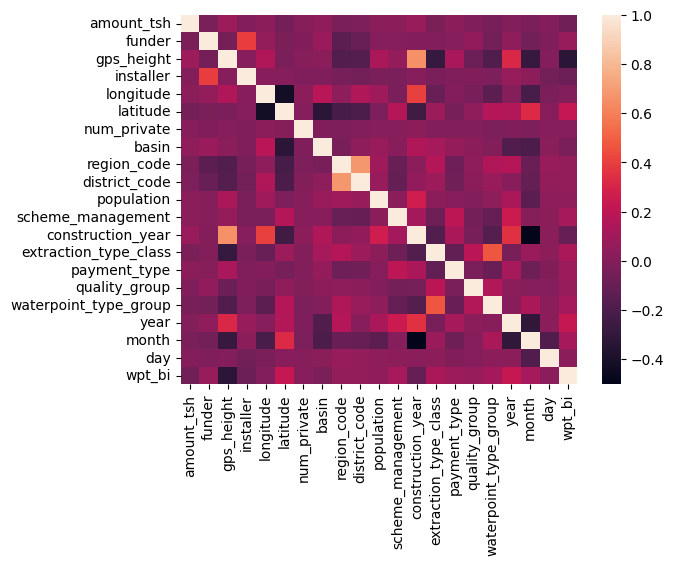

In [ ]:
df_correlacion = df[lista_correlacion]
correlation_mat = df_correlacion.corr()
sns.heatmap(correlation_mat)
plt.show()

# Outliers

amount_tsh


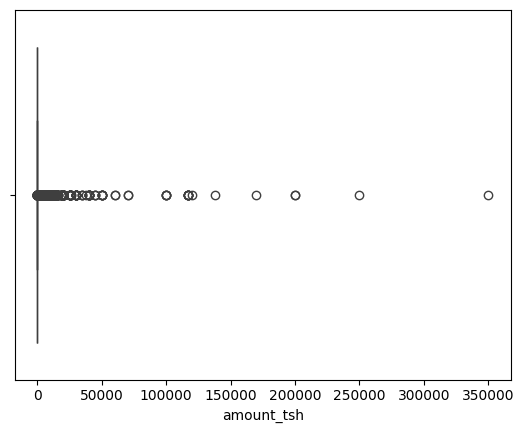

funder


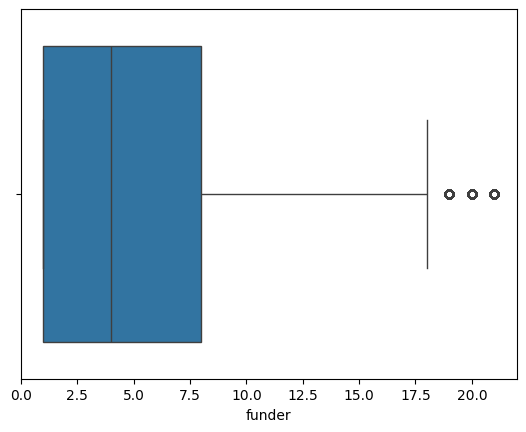

gps_height


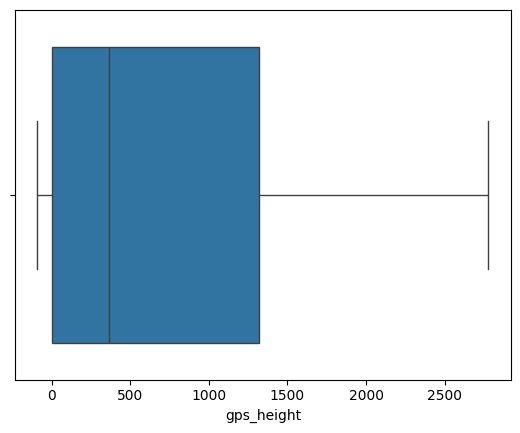

installer


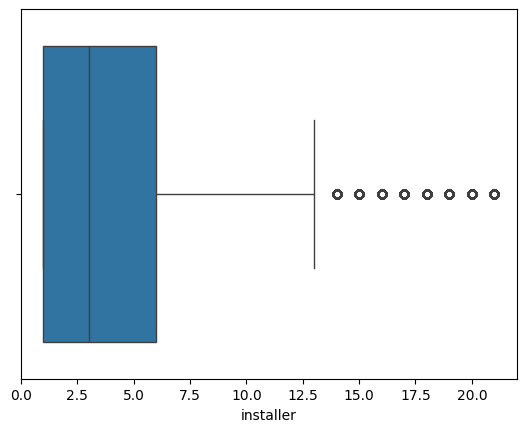

longitude


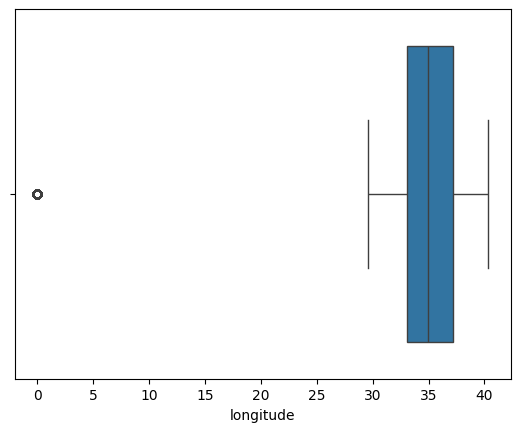

latitude


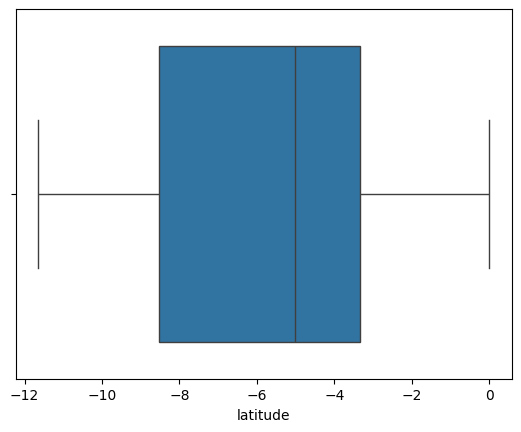

num_private


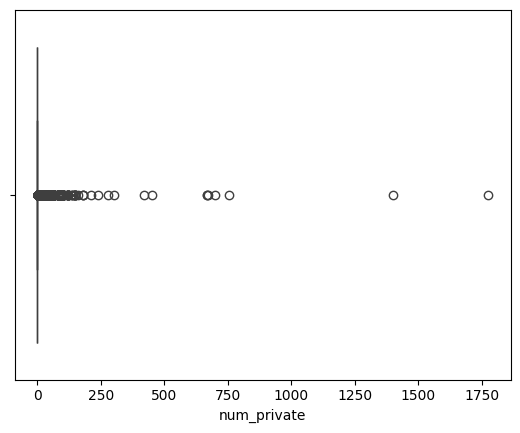

basin


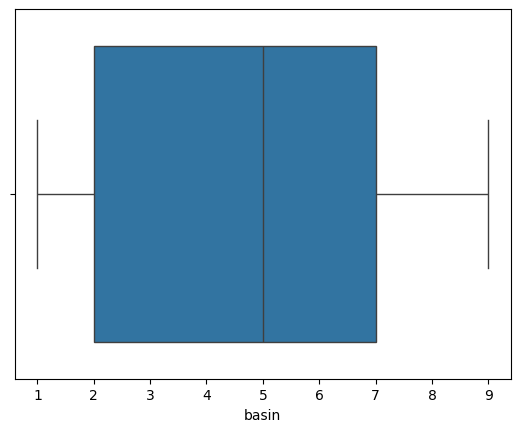

region_code


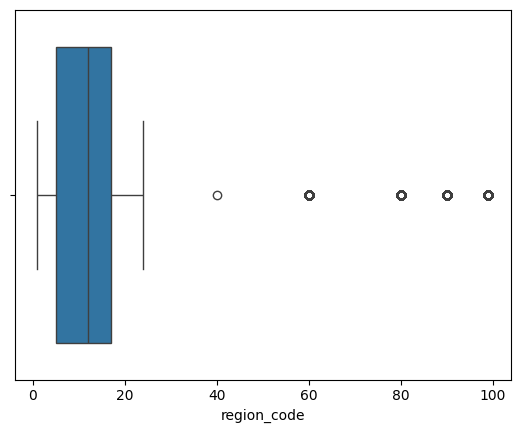

district_code


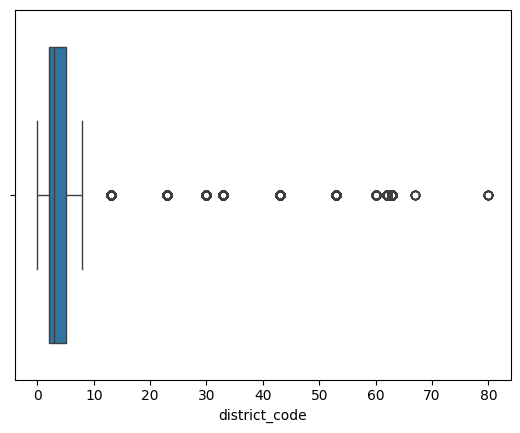

population


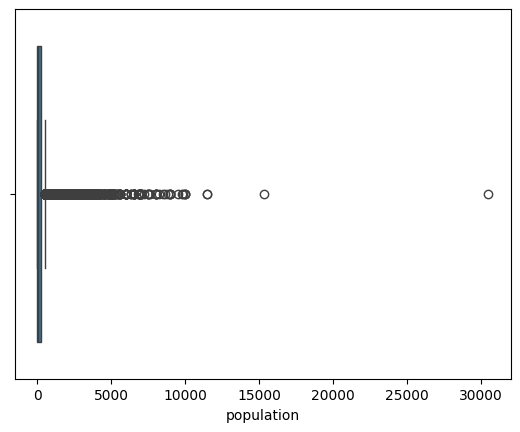

scheme_management


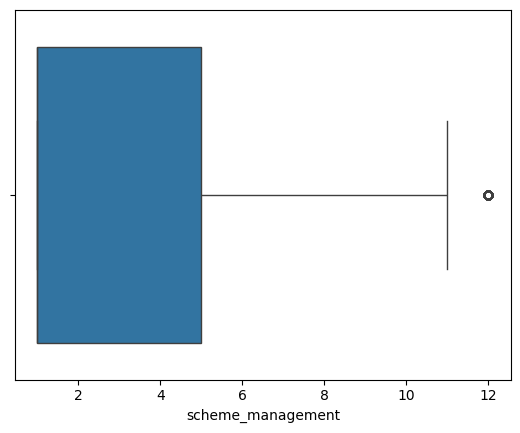

construction_year


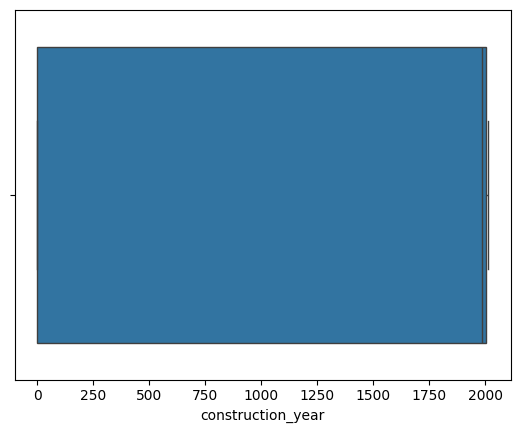

extraction_type_class


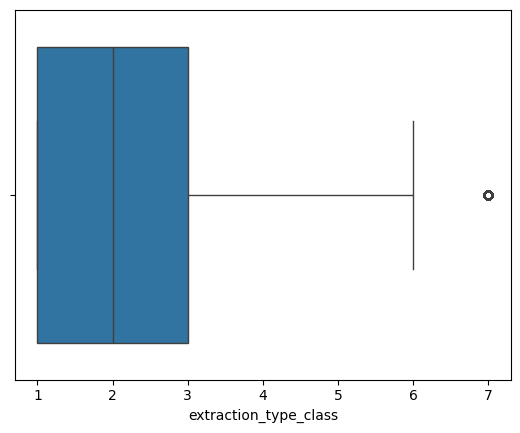

payment_type


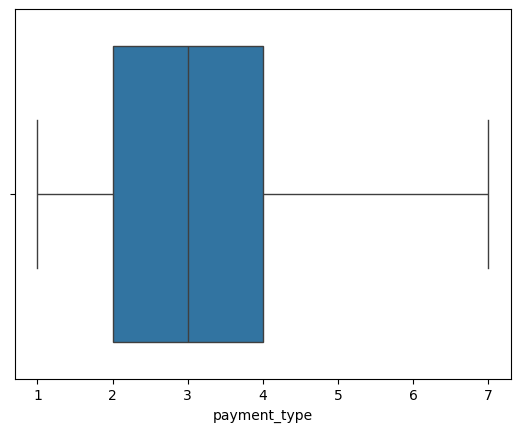

quality_group


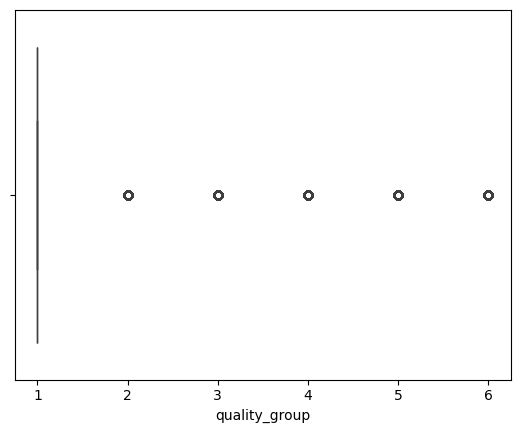

waterpoint_type_group


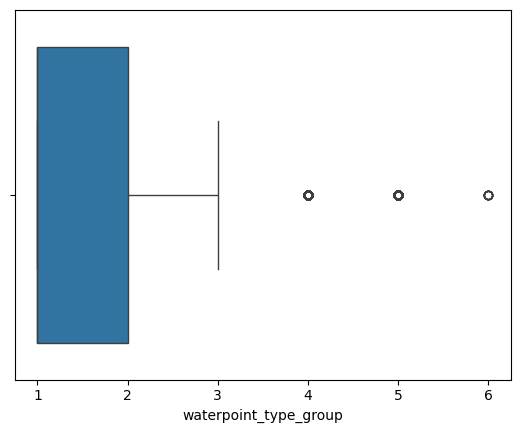

year


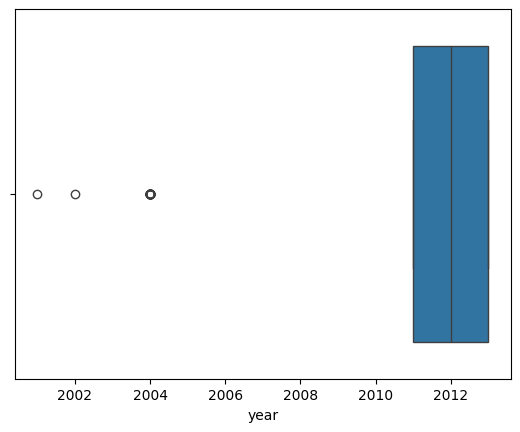

month


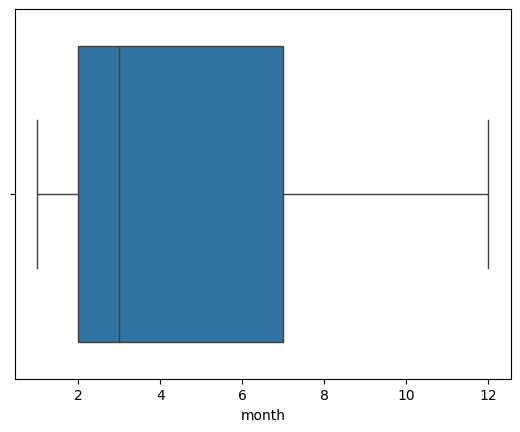

day


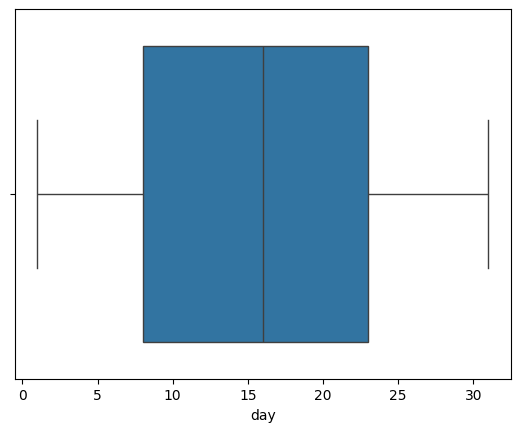

wpt_bi


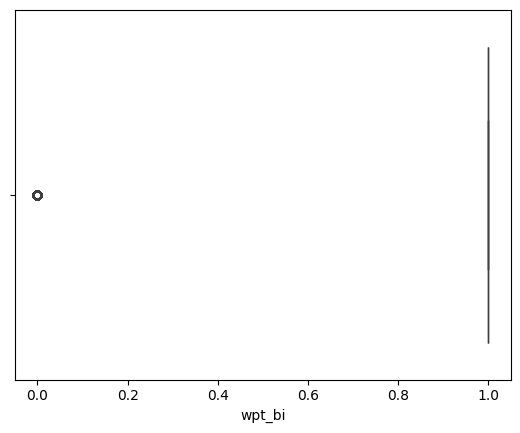

In [ ]:
for i in lista_correlacion:
  sns.boxplot(x = df[i])
  print(i)
  plt.show()

Vemos que hay outliers en **amount tsh, funder, installer, longitude, num_private, region_code, district_code** y **population**

In [ ]:
df.num_private.value_counts()

,count
num_private,
0,73299
1,94
6,92
5,60
8,58
...,...
55,1
1402,1
669,1


In [ ]:
df.num_private.value_counts(normalize=True)

,proportion
num_private,
0,0.987192
1,0.001266
6,0.001239
5,0.000808
8,0.000781
...,...
55,0.000013
1402,0.000013
669,0.000013


Vemos que num_private esta practicamente dominada por el valor 0. Vamos a convertirla a variable binaria, 0 no tiene numero privado o no hay datos y 1 si hay tiene numero privado o hay datos

In [ ]:
df['num_private_bi'] = df['num_private'].apply(lambda x: 0 if x == 0 else 1)

In [ ]:
df.num_private_bi.value_counts()

,count
num_private_bi,
0,73299
1,951


In [ ]:
# eliminamos la variable original:
df.drop(columns='num_private', inplace=True)

In [ ]:
df.amount_tsh.value_counts()

,count
amount_tsh,
0.00,52049
500.00,3874
50.00,3103
1000.00,1858
20.00,1812
...,...
0.25,1
59.00,1
3.00,1


In [ ]:
threshold = 3
z = np.abs(stats.zscore(df['amount_tsh']))
print(z)
print(np.where(z > threshold))

[1.95452942 0.10963671 0.10103601 ... 0.10963671 0.10963671 0.10963671]
(array([  194,   543,   559,   993,  1342,  1386,  1874,  2532,  2559,
        2654,  2857,  2866,  3033,  3054,  3228,  3245,  3330,  3585,
        4036,  4797,  5345,  5451,  5526,  5558,  5901,  6591,  6774,
        6954,  7364,  7747,  7756,  8156,  8345,  8463,  8464,  8524,
        9580,  9917,  9961, 10101, 10333, 10615, 10778, 10812, 10934,
       10939, 11112, 11349, 11452, 11496, 11794, 11796, 12114, 12250,
       12585, 12670, 12793, 12895, 13031, 13095, 13333, 13421, 13953,
       14098, 14823, 15285, 15363, 15367, 15396, 15587, 15913, 15989,
       16090, 16317, 17341, 17410, 17490, 17605, 17715, 17794, 18166,
       18538, 19384, 19561, 19946, 20312, 20500, 20692, 21052, 21567,
       22191, 22395, 22398, 22456, 22487, 22817, 23049, 23087, 23247,
       23252, 23446, 24257, 24520, 24675, 24956, 25065, 25542, 26014,
       26130, 27039, 27427, 27536, 27998, 28327, 28580, 29764, 30241,
       30372, 304

In [ ]:
df.loc[np.where(z > threshold)]

,id,amount_tsh,funder,gps_height,installer,longitude,latitude,basin,region_code,district_code,...,management_group_other,management_group_parastatal,management_group_unknown,management_group_user-group,quantity_dry,quantity_enough,quantity_insufficient,quantity_seasonal,quantity_unknown,num_private_bi
194,4807,25000.0,1,1768,1,34.716010,-9.129740,8,11,4,...,False,False,False,True,False,True,False,False,False,0
543,24691,40000.0,1,1711,3,35.408794,-8.112945,8,11,1,...,False,False,False,True,False,True,False,False,False,0
559,70070,12000.0,1,1020,3,35.348101,-9.891586,1,10,2,...,False,False,False,True,False,True,False,False,False,0
993,32502,20000.0,1,1540,3,36.686221,-3.339980,3,2,2,...,False,False,False,True,False,True,False,False,False,0
1342,55253,12000.0,1,1007,3,35.351222,-9.893956,1,10,2,...,False,False,False,True,False,True,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73720,69871,10000.0,1,1434,1,37.618067,-3.264331,3,3,1,...,False,False,False,False,False,False,True,False,False,0
74069,50215,12000.0,1,1011,3,35.338848,-9.887083,1,10,2,...,False,False,False,True,False,True,False,False,False,0
74109,47948,15000.0,1,1331,1,36.789922,-2.549068,5,2,6,...,False,False,False,True,False,False,True,False,False,0
74147,69564,50000.0,11,1435,6,34.756388,-5.403683,5,13,2,...,False,False,False,True,False,False,True,False,False,0


In [ ]:
df.loc[df['amount_tsh'] >= 10000]

,id,amount_tsh,funder,gps_height,installer,longitude,latitude,basin,region_code,district_code,...,management_group_other,management_group_parastatal,management_group_unknown,management_group_user-group,quantity_dry,quantity_enough,quantity_insufficient,quantity_seasonal,quantity_unknown,num_private_bi
194,4807,25000.0,1,1768,1,34.716010,-9.129740,8,11,4,...,False,False,False,True,False,True,False,False,False,0
543,24691,40000.0,1,1711,3,35.408794,-8.112945,8,11,1,...,False,False,False,True,False,True,False,False,False,0
559,70070,12000.0,1,1020,3,35.348101,-9.891586,1,10,2,...,False,False,False,True,False,True,False,False,False,0
993,32502,20000.0,1,1540,3,36.686221,-3.339980,3,2,2,...,False,False,False,True,False,True,False,False,False,0
1342,55253,12000.0,1,1007,3,35.351222,-9.893956,1,10,2,...,False,False,False,True,False,True,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73720,69871,10000.0,1,1434,1,37.618067,-3.264331,3,3,1,...,False,False,False,False,False,False,True,False,False,0
74069,50215,12000.0,1,1011,3,35.338848,-9.887083,1,10,2,...,False,False,False,True,False,True,False,False,False,0
74109,47948,15000.0,1,1331,1,36.789922,-2.549068,5,2,6,...,False,False,False,True,False,False,True,False,False,0
74147,69564,50000.0,11,1435,6,34.756388,-5.403683,5,13,2,...,False,False,False,True,False,False,True,False,False,0


Vemos que  los outliers de **amount tsh** usando z scores son los **valores maoyes o iguales que 10.000**. De momento los dejamos.

In [ ]:
threshold = 3
z = np.abs(stats.zscore(df['funder']))
print(z)
print(np.where(z > threshold))

[0.8538361  0.8538361  0.8538361  ... 0.94451157 0.8538361  0.40500727]
(array([], dtype=int64),)


en funder usando z-score, los outliers no se consideran extremos

In [ ]:
threshold = 3
z = np.abs(stats.zscore(df['longitude']))
print(z)
print(np.where(z > threshold))

[0.13143153 0.09501805 0.51524004 ... 0.10126203 0.20669069 0.10510381]
(array([   21,    53,   168, ..., 74166, 74231, 74241]),)


In [ ]:
df.loc[np.where(z > threshold)]

,id,amount_tsh,funder,gps_height,installer,longitude,latitude,basin,region_code,district_code,...,management_group_other,management_group_parastatal,management_group_unknown,management_group_user-group,quantity_dry,quantity_enough,quantity_insufficient,quantity_seasonal,quantity_unknown,num_private_bi
21,6091,0.0,3,0,3,0.0,-2.000000e-08,2,17,1,...,False,False,False,True,False,False,False,False,True,0
53,32376,0.0,8,0,10,0.0,-2.000000e-08,2,19,6,...,False,False,False,True,True,False,False,False,False,0
168,72678,0.0,1,0,1,0.0,-2.000000e-08,2,17,1,...,False,True,False,False,False,False,False,True,False,0
177,56725,0.0,1,0,3,0.0,-2.000000e-08,2,17,1,...,False,False,False,True,False,True,False,False,False,0
253,13042,0.0,7,0,3,0.0,-2.000000e-08,2,19,2,...,False,False,False,True,False,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74049,30454,0.0,1,0,1,0.0,-2.000000e-08,2,19,6,...,False,False,False,True,False,False,True,False,False,0
74076,44766,0.0,3,0,3,0.0,-2.000000e-08,2,17,1,...,False,False,False,True,False,True,False,False,False,0
74166,56279,0.0,8,0,12,0.0,-2.000000e-08,2,19,2,...,False,False,False,True,False,False,True,False,False,0
74231,37994,0.0,7,0,3,0.0,-2.000000e-08,2,19,2,...,False,False,False,True,False,True,False,False,False,0


In [ ]:
df.loc[df.longitude == 0]

,id,amount_tsh,funder,gps_height,installer,longitude,latitude,basin,region_code,district_code,...,management_group_other,management_group_parastatal,management_group_unknown,management_group_user-group,quantity_dry,quantity_enough,quantity_insufficient,quantity_seasonal,quantity_unknown,num_private_bi
21,6091,0.0,3,0,3,0.0,-2.000000e-08,2,17,1,...,False,False,False,True,False,False,False,False,True,0
53,32376,0.0,8,0,10,0.0,-2.000000e-08,2,19,6,...,False,False,False,True,True,False,False,False,False,0
168,72678,0.0,1,0,1,0.0,-2.000000e-08,2,17,1,...,False,True,False,False,False,False,False,True,False,0
177,56725,0.0,1,0,3,0.0,-2.000000e-08,2,17,1,...,False,False,False,True,False,True,False,False,False,0
253,13042,0.0,7,0,3,0.0,-2.000000e-08,2,19,2,...,False,False,False,True,False,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74049,30454,0.0,1,0,1,0.0,-2.000000e-08,2,19,6,...,False,False,False,True,False,False,True,False,False,0
74076,44766,0.0,3,0,3,0.0,-2.000000e-08,2,17,1,...,False,False,False,True,False,True,False,False,False,0
74166,56279,0.0,8,0,12,0.0,-2.000000e-08,2,19,2,...,False,False,False,True,False,False,True,False,False,0
74231,37994,0.0,7,0,3,0.0,-2.000000e-08,2,19,2,...,False,False,False,True,False,True,False,False,False,0


Vemos que todos los outliers son longitud 0, vamos a eliminarlos.

In [ ]:
df.loc[df.longitude == 0, 'longitude'] = np.nan

Vamos ahora a imputar los valores por la media de las observaciones

In [ ]:
df['longitude'] = df['longitude'].fillna(df['longitude'].mean())

In [ ]:
df.region_code.value_counts()

,count
region_code,
11,6608
17,6334
12,5759
3,5494
5,5079
18,4183
19,3824
2,3709
16,3533


In [ ]:
threshold = 3
z = np.abs(stats.zscore(df['region_code']))
print(z)
print(np.where(z > threshold))

[0.2436156  0.27041196 0.32752613 ... 0.12938726 0.30072977 0.30072977]
(array([    3,    26,    46, ..., 74167, 74222, 74225]),)


In [ ]:
df.loc[np.where(z > threshold)]

,id,amount_tsh,funder,gps_height,installer,longitude,latitude,basin,region_code,district_code,...,management_group_other,management_group_parastatal,management_group_unknown,management_group_user-group,quantity_dry,quantity_enough,quantity_insufficient,quantity_seasonal,quantity_unknown,num_private_bi
3,67743,0.0,2,263,1,38.486161,-11.155298,4,90,63,...,False,False,False,True,True,False,False,False,False,0
26,55012,500.0,1,200,1,39.370777,-9.942532,4,80,23,...,False,False,False,True,False,True,False,False,False,0
46,45111,20.0,1,240,9,39.087415,-11.000604,4,90,33,...,False,False,False,True,False,True,False,False,False,0
91,62591,0.0,1,212,1,38.962945,-10.476566,4,80,53,...,False,False,False,True,False,True,False,False,False,0
148,53167,0.0,1,1,1,39.600234,-10.027721,4,80,62,...,False,False,False,True,False,True,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74090,8698,50.0,1,-1,1,40.084576,-10.345254,4,99,1,...,False,False,False,True,False,True,False,False,False,0
74107,73197,0.0,1,88,1,40.110002,-10.448985,4,99,1,...,False,False,False,True,False,False,True,False,False,0
74167,64526,0.0,1,7,1,39.592783,-10.024897,4,80,62,...,False,False,False,True,False,True,False,False,False,0
74222,25901,50.0,1,640,9,39.297410,-10.925036,4,90,33,...,True,False,False,False,False,False,True,False,False,0


Para region_code, realmente no son outliers, porque 80 y 90 son solo el nombre en codigo de una region.

In [ ]:
df.district_code.value_counts()

,count
district_code,
1,15299
2,13929
3,12521
4,11253
5,5428
6,5108
7,4166
8,1282
30,1256


Dsitrict code es del mismo tipo que region code, los outliers no serian realmente outliers.

In [ ]:
df.population.value_counts()

,count
population,
0,26834
1,8782
200,2370
150,2328
250,2087
...,...
1115,1
1072,1
1239,1


Vamos a agrupar a la poblacion en grupos de acuerdo a la cantidad. Vamos a considerar un grupo para el 0 aparte porque hay muchos datos con poblacion nula.

In [ ]:
def population_bin(x):
    if x == 0:
        return 'nadie'
    elif x <= 100:
        return 'pequeno'
    elif x <= 500:
        return 'mediano'
    elif x <= 1000:
        return 'grande'
    else:
        return 'enorme'

df['population_bin'] = df['population'].apply(population_bin)

In [ ]:
df.population_bin.replace(('nadie', 'pequeno', 'mediano', 'grande', 'enorme'),(1,2,3,4,5),inplace=True)

/tmp/ipykernel_15153/1987155230.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.population_bin.replace(('nadie', 'pequeno', 'mediano', 'grande', 'enorme'),(1,2,3,4,5),inplace=True)
/tmp/ipykernel_15153/1987155230.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.population_bin.replace(('

In [ ]:
df.drop(columns='population', inplace=True)

# Fin del procesado de datos

Ahora vamos a separar los datos en los 2 conjuntos que teniamos al principio

In [ ]:
X_train = df[df['particion'] == 'train']
X_test = df[df['particion'] == 'test']

In [ ]:
X_train.drop(columns='particion', inplace=True)
X_test.drop(columns='particion', inplace=True)

/tmp/ipykernel_15153/3161748151.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop(columns='particion', inplace=True)
/tmp/ipykernel_15153/3161748151.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop(columns='particion', inplace=True)


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           59400 non-null  int64  
 1   amount_tsh                   59400 non-null  float64
 2   funder                       59400 non-null  int64  
 3   gps_height                   59400 non-null  int64  
 4   installer                    59400 non-null  int64  
 5   longitude                    59400 non-null  float64
 6   latitude                     59400 non-null  float64
 7   basin                        59400 non-null  int64  
 8   region_code                  59400 non-null  int64  
 9   district_code                59400 non-null  int64  
 10  scheme_management            59400 non-null  int64  
 11  construction_year            59400 non-null  int64  
 12  extraction_type_class        59400 non-null  int64  
 13  payment_type         

In [ ]:
X_train.set_index('id', inplace=True)
X_test.set_index('id', inplace=True)

Ahora vamos a convertir la variable objetivo a numerico

In [ ]:
train_label['status_group'] = train_label['status_group'].replace({'non functional': 0,'functional': 1, 'functional needs repair': 2})

/tmp/ipykernel_15153/1741568869.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_label['status_group'] = train_label['status_group'].replace({'non functional': 0,'functional': 1, 'functional needs repair': 2})


In [ ]:
train_label

,id,status_group
0,69572,1
1,8776,1
2,34310,1
3,67743,0
4,19728,1
...,...,...
59395,60739,1
59396,27263,1
59397,37057,1
59398,31282,1


In [ ]:
train_label.set_index('id', inplace=True)

In [ ]:
train_label

,status_group
id,
69572,1
8776,1
34310,1
67743,0
19728,1
...,...
60739,1
27263,1
37057,1


Ahora vamos a porbar un modelo que puede ser bastante bueno: RandomForest

In [ ]:
import sklearn
from sklearn.ensemble import RandomForestClassifier

In [ ]:
modelo = RandomForestClassifier()
modelo.fit(X_train, train_label)
y_pred = modelo.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Vamos ahora a ver que variables son las que el modelo considera las mas importantes, de este modo podemos crear un modelo nuevo con menos variables que sean mas significativas

In [ ]:
def plot_feature_importance(model,X_train):
  feat_importances = pd.DataFrame(model.feature_importances_,index=X_train.columns, columns= ['Importance'])
  feat_importances.sort_values(by='Importance',ascending=False,inplace=True)

  fig = px.bar(feat_importances, x=feat_importances.index,y='Importance' , title = 'Feature Importance')
  fig.update_layout(xaxis_title = 'Features',yaxis_title = 'Importance')
  fig.show()

  return feat_importances

In [ ]:
feature_importances = plot_feature_importance(modelo, X_train)
feature_importances

,Importance
longitude,0.144731
latitude,0.142041
quantity_dry,0.076796
gps_height,0.074026
day,0.061674
construction_year,0.052501
extraction_type_class,0.049017
waterpoint_type_group,0.043240
funder,0.028806
amount_tsh,0.027876


In [ ]:
feature_importances.index

Index(['longitude', 'latitude', 'quantity_dry', 'gps_height', 'day',
       'construction_year', 'extraction_type_class', 'waterpoint_type_group',
       'funder', 'amount_tsh', 'quantity_enough', 'payment_type',
       'district_code', 'month', 'installer', 'region_code', 'population_bin',
       'basin', 'scheme_management', 'quantity_insufficient', 'quality_group',
       'quantity_seasonal', 'source_class_surface', 'source_class_groundwater',
       'year', 'permit_True', 'permit_False', 'public_meeting_True',
       'management_group_user-group', 'public_meeting_False',
       'management_group_commercial', 'public_meeting_Unknown', 'wpt_bi',
       'permit_Unknown', 'quantity_unknown', 'management_group_parastatal',
       'management_group_other', 'num_private_bi', 'management_group_unknown',
       'source_class_unknown'],
      dtype='object')

In [ ]:
listam = ['longitude', 'latitude','quantity_dry', 'gps_height','day','construction_year', 'extraction_type_class', 'waterpoint_type_group','funder','amount_tsh',
          'payment_type','district_code','month', 'installer','population_bin']

In [ ]:
modelo2 = RandomForestClassifier()
modelo2.fit(X_train[listam], train_label)
y_pred2 = modelo2.predict(X_test[listam])

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



En la y_pred deshacemos el cambio de 0,1,2 por non functional, functional y functional needs repair respectivamente.

In [ ]:
y_pred_mapped = pd.Series(y_pred).replace({
    0: 'non functional',
    1: 'functional',
    2: 'functional needs repair'
})
y_pred_mapped

,0
0,non functional
1,functional
2,functional
3,non functional
4,functional
...,...
14845,non functional
14846,functional
14847,functional
14848,functional


Finalmente pasamos las predicciones a un DataFrame t lo guardamos en un archivo csv

In [ ]:
submission = pd.DataFrame({
    'id': X_test.index,
    'status_group': y_pred_mapped
})

In [ ]:
submission

,id,status_group
0,50785,non functional
1,51630,functional
2,17168,functional
3,45559,non functional
4,49871,functional
...,...,...
14845,39307,non functional
14846,18990,functional
14847,28749,functional
14848,33492,functional


In [ ]:
submission.to_csv('submission.csv', index=False)

Probamos ahora con el otro modelo, con menos variables.

In [ ]:
y_pred_mapped2 = pd.Series(y_pred2).replace({
    0: 'non functional',
    1: 'functional',
    2: 'functional needs repair'
})
y_pred_mapped2

,0
0,non functional
1,functional
2,functional
3,non functional
4,functional
...,...
14845,non functional
14846,functional
14847,functional
14848,functional


In [ ]:
submission2 = pd.DataFrame({
    'id': X_test.index,
    'status_group': y_pred_mapped2
})

In [ ]:
submission2

,id,status_group
0,50785,non functional
1,51630,functional
2,17168,functional
3,45559,non functional
4,49871,functional
...,...,...
14845,39307,non functional
14846,18990,functional
14847,28749,functional
14848,33492,functional


In [ ]:
submission2.to_csv('submission2.csv', index=False)

# **Resultados del envio:**
### submission : 0.8107
### Rango : 4302

### submission2: 0.7987

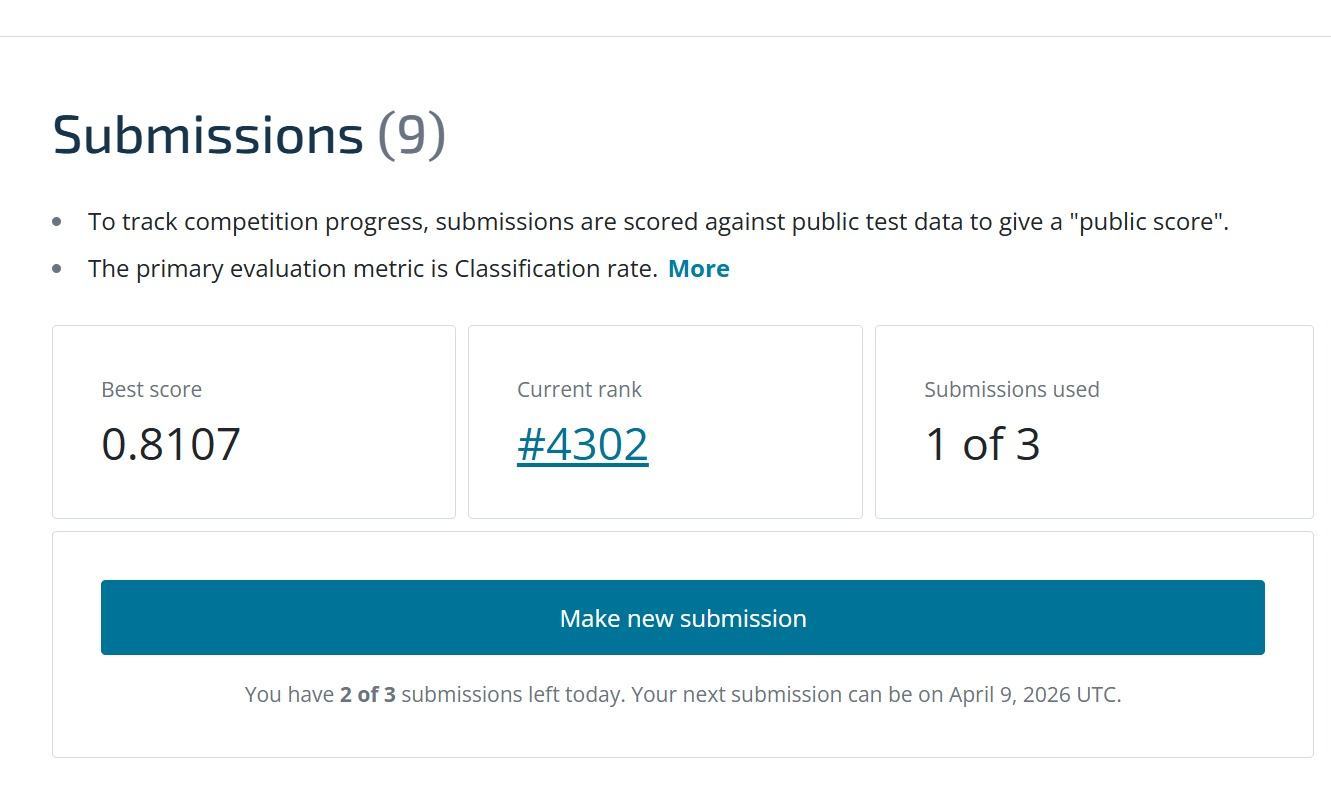

In [1]:
from IPython.display import Image, display

display(Image("submission1.jpeg"))

# Balanceo de datos

In [ ]:
train_label.status_group.value_counts()

,count
status_group,
1,32259
0,22824
2,4317


Observamos que "functional need repair" tiene pocas observaciones en comparacion con los otros 2 estados, lo que causa que al modelo le cueste detectar patrones para esta categoria.

Para ello, vamos a probar a hacer oversampling: vamos a generar datos de manera sintetica para "functional needs repair"

In [ ]:
!pip install imbalanced-learn

Antes de usar SMOTE, vamos a usar RandomForest, con las clases balanceadas.

In [ ]:
modeloRW = RandomForestClassifier(class_weight='balanced').fit(X_train, train_label)
y_predRW = modeloRW.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



In [ ]:
y_pred_mappedRW = pd.Series(y_predRW).replace({
    0: 'non functional',
    1: 'functional',
    2: 'functional needs repair'
})
y_pred_mappedRW

,0
0,functional
1,functional
2,functional
3,non functional
4,functional
...,...
14845,non functional
14846,functional
14847,functional
14848,functional


In [ ]:
submissionRW = pd.DataFrame({
    'id': X_test.index,
    'status_group': y_pred_mappedRW
})

In [ ]:
submissionRW.to_csv('submissionRW.csv', index=False)

Ahora usamos SMOTE

In [ ]:
counts = train_label['status_group'].value_counts()
print('Before oversampling, counts of label 1 : {}'.format(counts.get(1, 0)))
print('Before oversampling, counts of label 0 : {} '.format(counts.get(0, 0)))
print('Before oversampling, counts of label 2 : {} \n'.format(counts.get(2, 0)))

smote = SMOTE(
    sampling_strategy={2: 10000},
    random_state=42,
    k_neighbors=5
)

X_train_res, y_train_res = smote.fit_resample(X_train, train_label)

print('After oversampling, the shape of train_X: {}'.format(X_train_res.shape))
print('After oversampling, the shape of train_y: {}'.format(y_train_res.shape))

print('\nAfter oversampling, counts of label 1: {}'.format((y_train_res['status_group'] == 1).sum()))
print('After oversampling, counts of label 0: {}'.format((y_train_res['status_group'] == 0).sum()))
print('After oversampling, counts of label 2: {}'.format((y_train_res['status_group'] == 2).sum()))

Before oversampling, counts of label 1 : 32259
Before oversampling, counts of label 0 : 22824 
Before oversampling, counts of label 2 : 4317 

After oversampling, the shape of train_X: (65083, 40)
After oversampling, the shape of train_y: (65083, 1)

After oversampling, counts of label 1: 32259
After oversampling, counts of label 0: 22824
After oversampling, counts of label 2: 10000


In [ ]:
modelb = RandomForestClassifier().fit(X_train_res,y_train_res)
y_predb = modelb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



In [ ]:
y_pred_mappedb = pd.Series(y_predb).replace({
    0: 'non functional',
    1: 'functional',
    2: 'functional needs repair'
})
y_pred_mappedb

,0
0,non functional
1,functional
2,functional
3,non functional
4,functional
...,...
14845,non functional
14846,functional
14847,functional
14848,functional


In [ ]:
submissionb = pd.DataFrame({
    'id': X_test.index,
    'status_group': y_pred_mappedb
})

In [ ]:
submissionb.to_csv('submissionb.csv', index=False)

## **Resultados:**

score RandomForest balanceado: 0.8088

score SMOTE : 0.8086

No ha mejorado, probablemente porque al haber aumentado los 2, el modelo los detecta mejor pero los 0 y 1 los detecta peor y se compensa.



# Mejora del modelo

Tuneo de hiperparametros

In [ ]:
grid_param = {
    'n_estimators': [100,300,500],
    'criterion': ['gini','entropy'],
    'max_depth': [16,20,22,24],
    'max_features': ['auto','sqrt']
}

In [ ]:
from sklearn.model_selection import StratifiedKFold

stratified_kfold = StratifiedKFold(n_splits=5,
                                   shuffle=True,
                                   random_state=11)

In [ ]:
model_grid = GridSearchCV(estimator=modelo,
                          param_grid=grid_param,
                          scoring='accuracy',
                          cv = stratified_kfold,
                          n_jobs= -1)

La linea de debajo tarda 1 hora

In [ ]:
model_grid.fit(X_train,train_label)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning:


120 fits failed out of a total of 240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
37 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in 

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=11, shuffle=True),
             estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [16, 20, 22, 24],
                         'max_features': ['auto', 'sqrt'],
                         'n_estimators': [100, 300, 500]},
             scoring='accuracy')

In [ ]:
y_pred3 = model_grid.predict(X_test)

In [ ]:
y_pred_mapped3 = pd.Series(y_pred3).replace({
    0: 'non functional',
    1: 'functional',
    2: 'functional needs repair'
})
y_pred_mapped3

,0
0,functional
1,functional
2,functional
3,non functional
4,functional
...,...
14845,non functional
14846,functional
14847,functional
14848,functional


In [ ]:
submission3 = pd.DataFrame({
    'id': X_test.index,
    'status_group': y_pred_mapped3
})

In [ ]:
submission3.to_csv('submission3.csv', index=False)

## **Resultado:**

Score: 0.8178

rango: 2705

Nos quedamos con este modelo

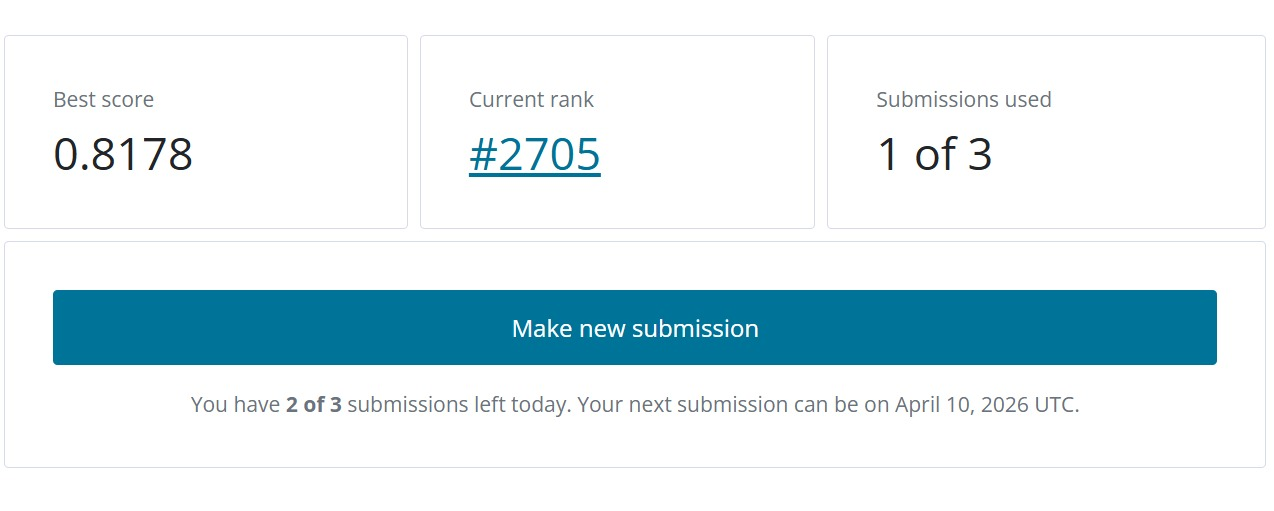

In [2]:
display(Image("submission2.jpeg"))

# AutoML H2O

In [ ]:
!pip -q install -U h2o

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 3.1 MB/s eta 0:00:00


Unimos train_label y train_val por el id

In [ ]:
data_train = pd.merge(train_val,train_label, on='id')

In [ ]:
data_train.drop(columns='particion',inplace=True)

In [ ]:
data_train

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,1
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,1
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,1
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,0
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59395,60739,10.0,2013-05-03,Germany Republi,1210,CES,37.169807,-3.253847,Area Three Namba 27,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,1
59396,27263,4700.0,2011-05-07,Cefa-njombe,1212,Cefa,35.249991,-9.070629,Kwa Yahona Kuvala,0,...,soft,good,enough,enough,river,river/lake,surface,communal standpipe,communal standpipe,1
59397,37057,0.0,2011-04-11,NaN,0,NaN,34.017087,-8.750434,Mashine,0,...,fluoride,fluoride,enough,enough,machine dbh,borehole,groundwater,hand pump,hand pump,1
59398,31282,0.0,2011-03-08,Malec,0,Musa,35.861315,-6.378573,Mshoro,0,...,soft,good,insufficient,insufficient,shallow well,shallow well,groundwater,hand pump,hand pump,1


El codigo de debajo tarda 1 hora

In [ ]:
import h2o
from h2o.automl import H2OAutoML

h2o.init()

# Convertimos a H2OFrame
train_h2o = h2o.H2OFrame(data_train)
test_h2o = h2o.H2OFrame(test_val)

target = "status_group"
features = [c for c in train_h2o.columns if c != target]

# Para clasificación, la variable objetivo debe ser factor
train_h2o[target] = train_h2o[target].asfactor()

aml = H2OAutoML(
    max_models=2,          # ajusta según tiempo de clase
    seed=123,
    sort_metric="AUC",
    exclude_algos=None      # puedes excluir si quieres simplificar
)
aml.train(x=features, y=target, training_frame=train_h2o)

aml.leaderboard.head()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmprac1mzfs
  JVM stdout: /tmp/tmprac1mzfs/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmprac1mzfs/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,05 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,26 days
H2O_cluster_name:,H2O_from_python_unknownUser_cae7t2
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
06:31:17.23: _train param, Dropping bad and constant columns: [recorded_by]

██
06:43:34.385: _train param, Dropping bad and constant columns: [recorded_by]

████████████████████████████████████████████████████████████
07:26:22.660: _train param, Dropping unused columns: [recorded_by]

█| (done) 100%


model_id,auc,mean_per_class_error,logloss,rmse,mse
XGBoost_1_AutoML_1_20260408_63116,nan,0.347939,0.491282,0.395403,0.156344
StackedEnsemble_BestOfFamily_1_AutoML_1_20260408_63116,nan,0.353754,0.491417,0.398337,0.158672
GLM_1_AutoML_1_20260408_63116,nan,0.435854,0.588987,0.441462,0.194888


In [ ]:
best_model = aml.leader

In [ ]:
preds = best_model.predict(test_h2o)

xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.12/dist-packages/h2o/job.py:81: UserWarning:

Test/Validation dataset column 'wpt_name' has levels not trained on: ["21", "<Kwa Maluku", "Abada", "Abaview", "Abdala Dewji", "Abdalah Abdalah", "Abdalah Jumanne", "Abdalah Mchela", "Abdallar Seif", "Abdu Mkhondya", ...8264 not listed..., "Zhanati", "Ziga", "Zilipendwa", "Zilpa", "Zimbili Kwa Kitambo", "Zinga 1", "Zongwe", "Zonola", "Zugwitukile", "Zuhura Mmole"]

/usr/local/lib/python3.12/dist-packages/h2o/job.py:81: UserWarning:

Test/Validation dataset column 'subvillage' has levels not trained on: ["10C", "14Kambarage", "21", "21A", "24A", "28A", "32", "55 A", "57 A", "Agake", ...2118 not listed..., "Wiyogolo", "Yichobela", "You'Re", "Zabaga", "Zamang'Ombe", "Zara", "Zelezeta Kati", "Zilamakazi", "Zimanimoto", "Zumve"]

/usr/local/lib/python3.12/dist-packages/h2o/job.py:81: UserWarning:

Test/Validation dataset column 'scheme_name' has levels not trained on: ["AI", "AVEDA", "BL Donyo shuleni", "BL Eligad branch l

In [ ]:
preds
# con preds obtengo la prediccion y la probabilidad de cada clase (44 % de ser 0, 47% de ser 1 , luego la prediccion es 1)

predict,p0,p1,p2
1,0.455684,0.486751,0.0575653
1,0.238226,0.708064,0.0537098
1,0.0463036,0.886007,0.0676896
0,0.996729,0.00281154,0.000459319
1,0.0214452,0.956275,0.0222794
1,0.117331,0.862644,0.0200245
0,0.599247,0.396922,0.00383068
0,0.994225,0.00494055,0.000834116
0,0.520048,0.118803,0.361149
1,0.0153433,0.977217,0.00743915


In [ ]:
y_pred4 = preds['predict'].as_data_frame().values.flatten()
y_pred4

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning:

Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)




array([1, 1, 1, ..., 1, 1, 0])

In [ ]:
y_pred_mapped4 = pd.Series(y_pred4).replace({
    0: 'non functional',
    1: 'functional',
    2: 'functional needs repair'
})
y_pred_mapped4

,0
0,functional
1,functional
2,functional
3,non functional
4,functional
...,...
14845,non functional
14846,functional
14847,functional
14848,functional


In [ ]:
submission4 = pd.DataFrame({
    'id': X_test.index,
    'status_group': y_pred_mapped4
})
submission4

,id,status_group
0,50785,functional
1,51630,functional
2,17168,functional
3,45559,non functional
4,49871,functional
...,...,...
14845,39307,non functional
14846,18990,functional
14847,28749,functional
14848,33492,functional


In [ ]:
submission4.to_csv('submission4.csv', index=False)

## **Resultado del modelo AutoML:**

Score: 0.8098

No es tan bueno como el anterior, porque hemos usado todos los datos sin depurar.